In [99]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import folium

## Data Load

In [2]:
df = pd.read_csv("Delhi metro.csv")
df.head()

,ID (Station ID),Station Names,Dist. From First Station(km),Metro Line,Opened(Year),Layout,Latitude,Longitude
0,1,Shaheed Sthal(First Station),0.0,Red line,08-03-2019,Elevated,28.670611,77.415582
1,2,Hindon River,1.0,Red line,08-03-2019,Elevated,28.878965,77.415483
2,3,Arthala,2.5,Red line,08-03-2019,Elevated,28.676999,77.391892
3,4,Mohan Nagar,3.2,Red line,08-03-2019,Elevated,28.606319,77.106082
4,5,Shyam park,4.5,Red line,08-03-2019,Elevated,28.698807,28.698807


## Data Clean

In [3]:
df.shape

(285, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID (Station ID)               285 non-null    int64  
 1   Station Names                 285 non-null    object 
 2   Dist. From First Station(km)  285 non-null    float64
 3   Metro Line                    285 non-null    object 
 4   Opened(Year)                  285 non-null    object 
 5   Layout                        285 non-null    object 
 6   Latitude                      285 non-null    float64
 7   Longitude                     285 non-null    float64
dtypes: float64(3), int64(1), object(4)
memory usage: 17.9+ KB


In [5]:
df['Opened(Year)'] = df['Opened(Year)'].astype('datetime64[ns]')
df['Year'] = df['Opened(Year)'].dt.year
df.dtypes

ID (Station ID)                          int64
Station Names                           object
Dist. From First Station(km)           float64
Metro Line                              object
Opened(Year)                    datetime64[ns]
Layout                                  object
Latitude                               float64
Longitude                              float64
Year                                     int32
dtype: object

In [6]:
df.isnull().sum()

ID (Station ID)                 0
Station Names                   0
Dist. From First Station(km)    0
Metro Line                      0
Opened(Year)                    0
Layout                          0
Latitude                        0
Longitude                       0
Year                            0
dtype: int64

## Metro Network & Infrastructure 

1. How many stations exist on each metro line?

In [7]:
Total_stations = df.groupby('Metro Line')['Station Names'].count().reset_index().sort_values(by='Station Names',ascending=False)
Total_stations.rename(columns={'Station Names':'Total Stations'})

,Metro Line,Total Stations
1,Blue line,49
8,Pink line,38
12,Yellow line,37
11,Voilet line,34
10,Red line,29
6,Magenta line,25
0,Aqua line,21
4,Green line,21
9,Rapid Metro,11
2,Blue line branch,8


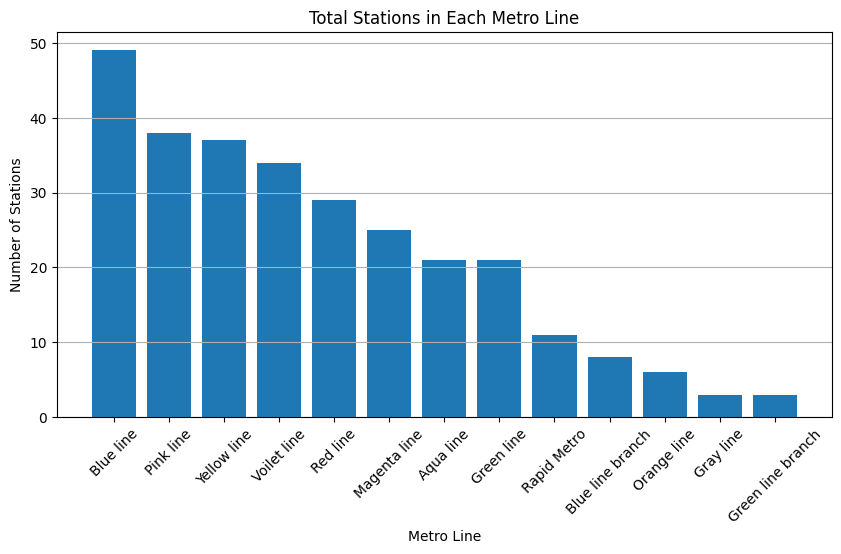

'Blue Line has the highest number of stations,\nwhile branch and smaller lines like the Gray Line and Green Line branch have the fewest, indicating uneven station distribution across metro lines.'

In [8]:
plt.figure(figsize=(10,5))

plt.bar(Total_stations['Metro Line'], Total_stations['Station Names'])

plt.title("Total Stations in Each Metro Line")
plt.xlabel("Metro Line")
plt.ylabel("Number of Stations")

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

'''Blue Line has the highest number of stations,
while branch and smaller lines like the Gray Line and Green Line branch have the fewest, indicating uneven station distribution across metro lines.'''

2. What is the total length (in km) covered by each metro line? 

In [9]:
Total_length = df.groupby('Metro Line')['Dist. From First Station(km)'].max().sort_values().reset_index()
Total_length.rename(columns={'Dist. From First Station(km)':'Total Length (km)'},inplace=True)
Total_length

,Metro Line,Total Length (km)
0,Green line branch,2.1
1,Gray line,3.9
2,Blue line branch,8.1
3,Rapid Metro,10.0
4,Orange line,20.8
5,Green line,24.8
6,Aqua line,27.1
7,Red line,32.7
8,Magenta line,33.1
9,Voilet line,43.5


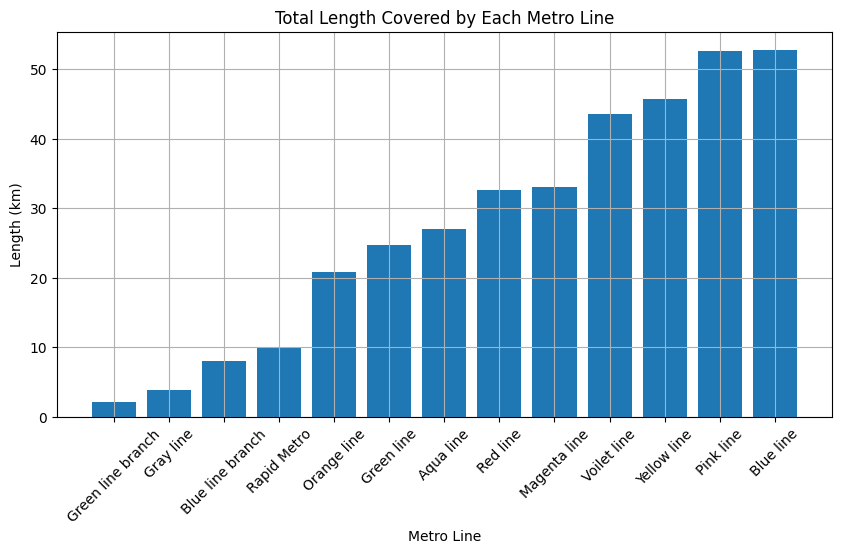

'Blue and Pink Lines cover the longest distances, while branch and smaller lines like the Green Line branch and Gray Line cover the shortest,\nhighlighting uneven network coverage.'

In [10]:
plt.figure(figsize=(10,5))
plt.bar(Total_length['Metro Line'], Total_length['Total Length (km)'])
plt.xticks(rotation=45)
plt.title("Total Length Covered by Each Metro Line")
plt.xlabel("Metro Line")
plt.ylabel("Length (km)")
plt.grid()

plt.show()

'''Blue and Pink Lines cover the longest distances, while branch and smaller lines like the Green Line branch and Gray Line cover the shortest,
highlighting uneven network coverage.'''

3.  Which metro line has the longest and shortest average distance between stations?

In [11]:
df['Interstation Distance'] = df.groupby('Metro Line')['Dist. From First Station(km)'].diff()

In [12]:
avg_dist = df.groupby('Metro Line')['Interstation Distance'].mean().reset_index()
avg_dist = avg_dist.sort_values(by='Interstation Distance', ascending=False)

avg_dist

,Metro Line,Interstation Distance
7,Orange line,4.160000
3,Gray line,1.950000
8,Pink line,1.421622
6,Magenta line,1.379167
0,Aqua line,1.355000
11,Voilet line,1.318182
12,Yellow line,1.269444
4,Green line,1.240000
10,Red line,1.167857
2,Blue line branch,1.157143


In [13]:
longest = avg_dist.loc[avg_dist['Interstation Distance'].idxmax()]
shortest = avg_dist.loc[avg_dist['Interstation Distance'].idxmin()]

In [14]:
display(longest,"/n",shortest)

Metro Line               Orange line
Interstation Distance           4.16
Name: 7, dtype: object

'/n'

Metro Line               Rapid Metro
Interstation Distance            1.0
Name: 9, dtype: object

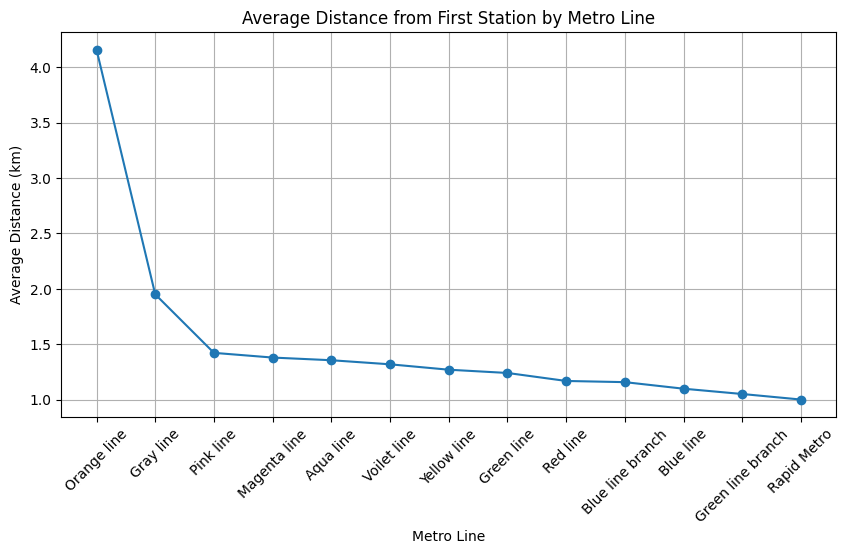

'Orange Line has the highest average distance from the first station, while Rapid Metro and branch lines have the lowest,\nindicating differences in how widely stations are spread across lines.'

In [15]:
plt.figure(figsize=(10,5))

plt.plot(avg_dist['Metro Line'], 
         avg_dist['Interstation Distance'], 
         marker='o')

plt.title("Average Distance from First Station by Metro Line")
plt.xlabel("Metro Line")
plt.ylabel("Average Distance (km)")

plt.xticks(rotation=45)
plt.grid()

plt.show()

'''Orange Line has the highest average distance from the first station, while Rapid Metro and branch lines have the lowest,
indicating differences in how widely stations are spread across lines.'''

4. What is the distribution of station layouts (underground, elevated, ground level) across all lines? 

In [16]:
Total_layouts = df['Layout'].value_counts().reset_index()
Total_layouts

,Layout,count
0,Elevated,214
1,Underground,68
2,At-Grade,3


5. How has the Delhi Metro network expanded year by year?

In [72]:
stations_count = df.groupby('Year')['Station Names'].count().reset_index()
stations_count = stations_count.rename(columns={'Station Names':'Total_stations'})
stations_count

,Year,Total_stations
0,2002,6
1,2003,4
2,2004,11
3,2005,28
4,2006,9
5,2008,3
6,2009,17
7,2010,54
8,2011,13
9,2013,5


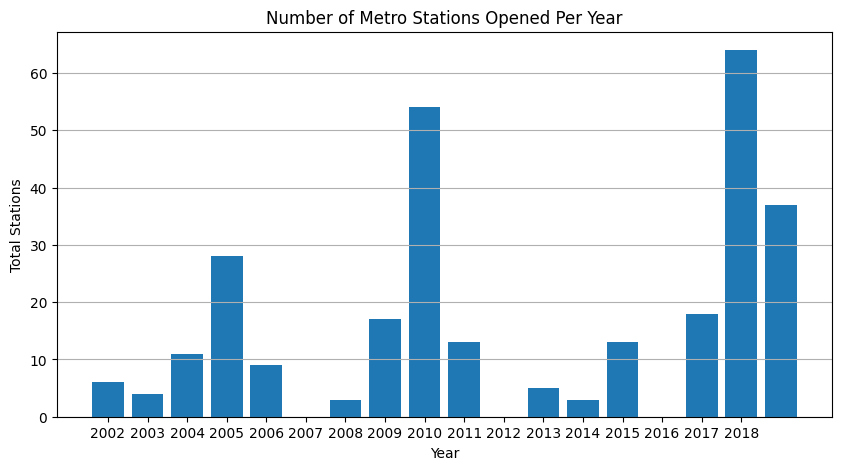

'the number of metro stations opened each year varies significantly,\nwith peak expansions around 2010 and 2018, indicating phases of rapid development.'

In [74]:
stations_count['Year'] = stations_count['Year'].astype(int)

plt.figure(figsize=(10,5))
plt.bar(stations_count['Year'], stations_count['Total_stations'])

plt.title("Number of Metro Stations Opened Per Year")
plt.xlabel("Year")
plt.ylabel("Total Stations")

# Show years with gap (no decimals)
plt.xticks(np.arange(stations_count['Year'].min(),
                     stations_count['Year'].max()))

plt.grid(axis='y')
plt.show()

'''the number of metro stations opened each year varies significantly,
with peak expansions around 2010 and 2018, indicating phases of rapid development.'''

## Temporal Expansion & Trends

6. In which year did the most metro stations open?

In [50]:
print("most metro stations opened in", stations_count.max())

most metro stations opened in Year             2019
Station Names      64
dtype: int64


7. What is the trend of station openings per year across different lines? 

In [80]:
stations_trend = df.groupby(['Year', 'Metro Line'])['Station Names'].count().reset_index()
stations_trend.rename(columns={'Station Names': 'Total_Stations'}, inplace=True)

stations_trend.head(10)

,Year,Metro Line,Total_Stations
0,2002,Red line,6
1,2003,Red line,4
2,2004,Red line,7
3,2004,Yellow line,4
4,2005,Blue line,22
5,2005,Yellow line,6
6,2006,Blue line,9
7,2008,Red line,3
8,2009,Blue line,11
9,2009,Blue line branch,1


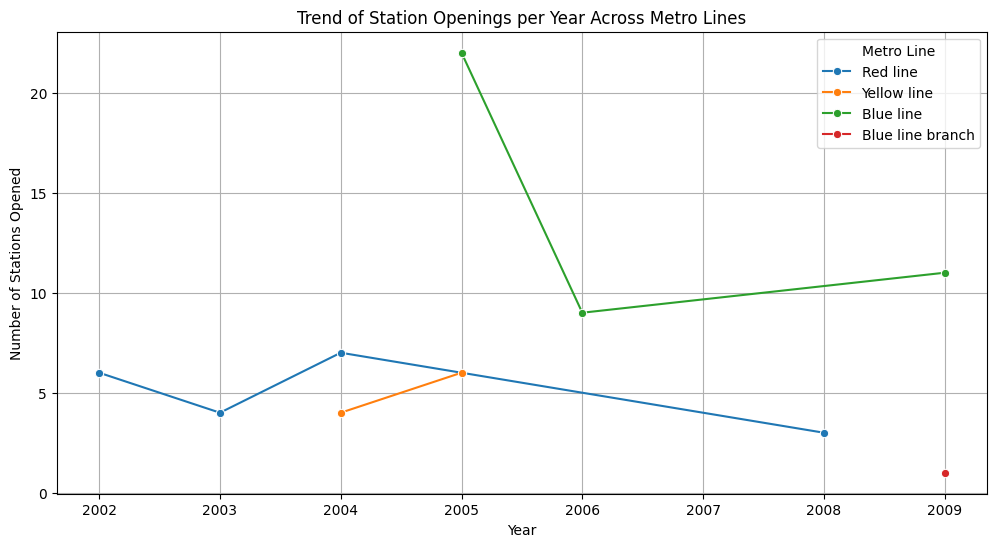

'Red line declines over time after a peak in 2004, indicating reduced expansion activity,\nwhile Yellow line shows limited and short-term growth, and **Blue line branch begins late with minimal stations added.'

In [126]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=stations_trend.head(10),
    x='Year',
    y='Total_Stations',
    hue='Metro Line',
    marker='o'
)

plt.title('Trend of Station Openings per Year Across Metro Lines')
plt.xlabel('Year')
plt.ylabel('Number of Stations Opened')

plt.legend(title='Metro Line')
plt.grid(True)

plt.show()

'''Blue line shows a major expansion spike around 2005,
opening the highest number of stations, followed by a sharp drop in 2006 and then gradual growth again'''

'''Red line declines over time after a peak in 2004, indicating reduced expansion activity,
while Yellow line shows limited and short-term growth, and **Blue line branch begins late with minimal stations added.'''

8. Are newer stations more likely to be underground or elevated?

In [23]:
df['Year'] = df['Opened(Year)'].dt.year

df['Era'] = df['Year'].apply(lambda x: 'New' if x >= 2010 else 'Old')

In [24]:
result = df.groupby(['Era', 'Layout']).size().unstack(fill_value=0)
display(result)

Layout,At-Grade,Elevated,Underground
Era,,,
New,1,152,54
Old,2,62,14


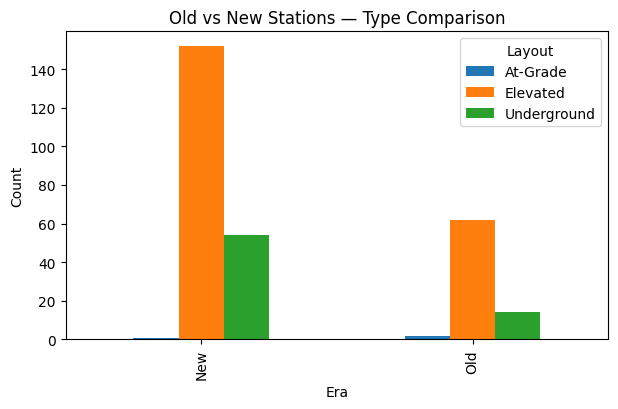

In [25]:
result.plot(kind='bar', figsize=(7,4))
plt.title("Old vs New Stations — Type Comparison")
plt.ylabel("Count")
plt.show()

#Newer stations are more likely to be Elevated
#New stations have ~150 Elevated vs ~55 Underground — Elevated dominates heavily
#Even in Old stations, Elevated (~62) was more common than Underground (~15)
#So Elevated has always been preferred, but the gap is much larger in newer stations

## Accessibility & Planning

9.  Which metro stations are the farthest from the first station in each line?

In [26]:
farthest_stations = df.loc[df.groupby('Metro Line')['Dist. From First Station(km)'].idxmax()
][['Metro Line', 'Station Names', 'Dist. From First Station(km)']]

farthest_stations = farthest_stations.sort_values(by='Dist. From First Station(km)', ascending=False)
farthest_stations

,Metro Line,Station Names,Dist. From First Station(km)
114,Blue line,Noida Sector 62,52.7
254,Pink line,Shiv Vihar,52.6
65,Yellow line,Huda City Centre,45.7
191,Voilet line,Raja Nahar Singh,43.5
216,Magenta line,Botanical Garden [Conn: Blue],33.1
28,Red line,Rithala(last station),32.7
275,Aqua line,Depot Greater Noida,27.1
146,Green line,Brigadier Hoshiar Singh,24.8
284,Orange line,Dwarka Sector 21 [Conn: Blue],20.8
157,Rapid Metro,DLF Phase 3,10.0


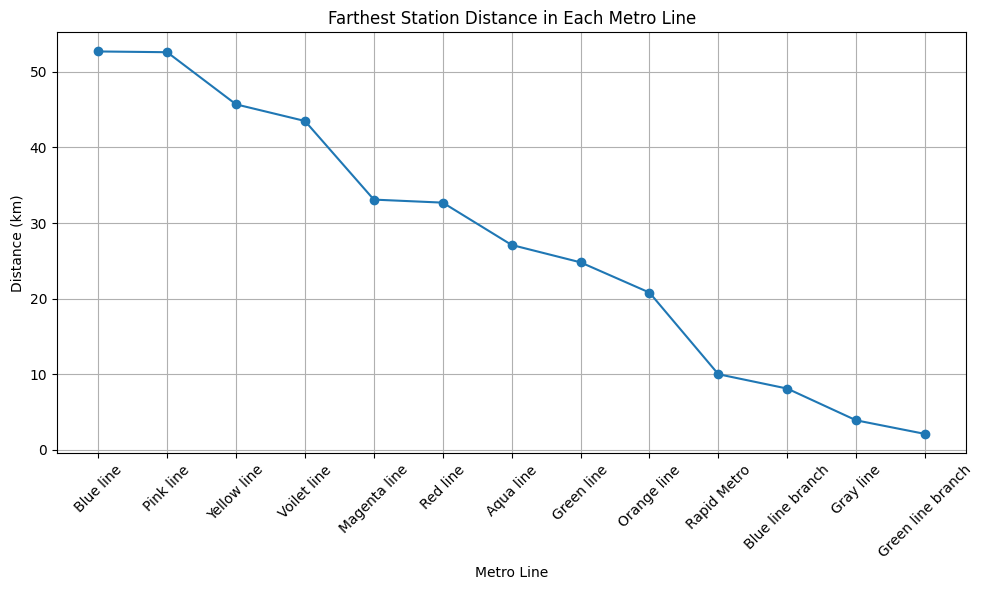

'Blue and Pink lines have the longest reach (farthest stations),\nwhile branch and smaller lines like the Green Line branch and Gray line cover the shortest distances.'

In [27]:
plt.figure(figsize=(10,6))

plt.plot(farthest_stations['Metro Line'],
         farthest_stations['Dist. From First Station(km)'],
         marker='o')

plt.xticks(rotation=45)
plt.xlabel('Metro Line')
plt.ylabel('Distance (km)')
plt.title('Farthest Station Distance in Each Metro Line')

plt.grid(True)
plt.tight_layout()
plt.show()

'''Blue and Pink lines have the longest reach (farthest stations),
while branch and smaller lines like the Green Line branch and Gray line cover the shortest distances.'''

10. Which station is geographically closest to the city centre (based on coordinates)? 

In [123]:
city_centre = (28.6315, 77.2167)

df['distance_km'] = np.sqrt(
    ((df['Latitude'] - city_centre[0]) * 111)**2 +
    ((df['Longitude'] - city_centre[1]) * 111 * np.cos(np.radians(city_centre[0])))**2
)

print(df.nsmallest(5, 'distance_km')[['Station Names', 'Metro Line', 'Latitude', 'Longitude', 'distance_km']])

                  Station Names   Metro Line  Latitude  Longitude  distance_km
94   Rajiv Chowk [Conn: Yellow]    Blue line  28.63282   77.21826     0.211111
44     Rajiv Chowk [Conn: Blue]  Yellow line  28.63282   77.21826     0.211111
280             Shivaji Stadium  Orange line  28.62901   77.21190     0.543219
95                   Barakhamba    Blue line  28.63003   77.22436     0.763920
45                  Patel Chowk  Yellow line  28.62295   77.21389     0.987748


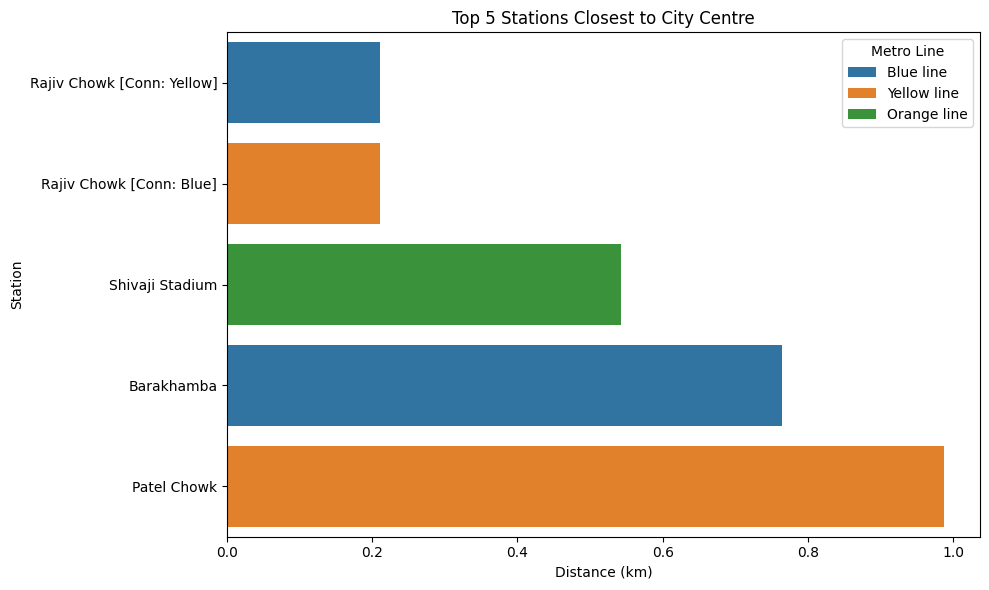

'Stations like Barakhamba and Patel Chowk are slightly farther but still within ~1 km,\nindicating a dense cluster of metro stations in central Delhi with strong accessibility.'

In [128]:
closest = df.nsmallest(5, 'distance_km')

plt.figure(figsize=(10,6))

sns.barplot(
    data=closest,
    x='distance_km',
    y='Station Names',
    hue='Metro Line'
)

plt.title('Top 5 Stations Closest to City Centre')
plt.xlabel('Distance (km)')
plt.ylabel('Station')

plt.tight_layout()
plt.show()

'''Rajiv Chowk (both Blue & Yellow line connections) is the closest to the city centre,
followed by Shivaji Stadium, showing that central connectivity is concentrated around key interchange hubs.'''

'''Stations like Barakhamba and Patel Chowk are slightly farther but still within ~1 km,
indicating a dense cluster of metro stations in central Delhi with strong accessibility.'''

## KPI & Performance Indicators

11. What are the key performance metrics for each line (e.g., stations per km, avg interstation 
distance)? 

In [31]:
analysis = df.groupby('Metro Line').agg({
    'Station Names': 'count',
    'Dist. From First Station(km)': 'max'
}).reset_index()

analysis.rename(columns={
    'Station Names': 'Total Stations',
    'Dist. From First Station(km)': 'Total Length (km)'
}, inplace=True)

# Stations per km (density)
analysis['Stations per km'] = analysis['Total Stations'] / analysis['Total Length (km)']

# Average interstation distance
analysis['Avg Interstation Distance (km)'] = analysis['Total Length (km)'] / (analysis['Total Stations'] - 1)

analysis = analysis.sort_values(by='Total Length (km)', ascending=False)

np.round(analysis,1)

,Metro Line,Total Stations,Total Length (km),Stations per km,Avg Interstation Distance (km)
1,Blue line,49,52.7,0.9,1.1
8,Pink line,38,52.6,0.7,1.4
12,Yellow line,37,45.7,0.8,1.3
11,Voilet line,34,43.5,0.8,1.3
6,Magenta line,25,33.1,0.8,1.4
10,Red line,29,32.7,0.9,1.2
0,Aqua line,21,27.1,0.8,1.4
4,Green line,21,24.8,0.8,1.2
7,Orange line,6,20.8,0.3,4.2
9,Rapid Metro,11,10.0,1.1,1.0


12. How does the infrastructure type vary by line or year of launch?

In [87]:
by_line = df.groupby(['Metro Line', 'Layout']).size().unstack(fill_value=0)
by_line['Total'] = by_line.sum(axis=1)
print("=== Infrastructure Type by Line ===")
print(by_line.to_string())

# Layout by Year
by_year = df.groupby(['Year', 'Layout']).size().unstack(fill_value=0)
print("\n=== Infrastructure Type by Year ===")
print(by_year.to_string())

=== Infrastructure Type by Line ===
Layout             At-Grade  Elevated  Underground  Total
Metro Line                                               
Aqua line                 0        21            0     21
Blue line                 1        44            4     49
Blue line branch          1         7            0      8
Gray line                 0         2            1      3
Green line                0        21            0     21
Green line branch         1         2            0      3
Magenta line              0        10           15     25
Orange line               0         1            5      6
Pink line                 0        26           12     38
Rapid Metro               0        11            0     11
Red line                  0        29            0     29
Voilet line               0        23           11     34
Yellow line               0        17           20     37

=== Infrastructure Type by Year ===
Layout  At-Grade  Elevated  Underground
Year             

13. Can we identify underserved areas that need new stations? 

In [98]:
df['gap'] = df.groupby('Metro Line')['Dist. From First Station(km)'].transform(
    lambda x: x.sort_values().diff().shift(-1))

print(df[df['gap'] > 2][['Metro Line', 'Station Names', 'gap']].sort_values('gap', ascending=False).to_string(index=False))

  Metro Line                      Station Names  gap
 Orange line                    Shivaji Stadium  6.4
 Orange line           Dhaula Kuan [Conn: Pink]  6.2
   Pink line                        Delhi Cantt  3.6
   Pink line  Sarai Kale Khan Hazrat Nizamuddin  3.6
 Orange line                     Delhi Aerocity  3.4
 Orange line                        IGI Airport  2.9
 Yellow line                           Ghitorni  2.7
Magenta line                              Palam  2.6
 Voilet line                    Badarpur Border  2.5
   Aqua line                   Noida Sector 148  2.5
   Pink line                  Punjabi Bagh West  2.5
   Gray line                             Nangli  2.4
 Yellow line                         Arjan Garh  2.3
  Green line       Mundka Industrial Area (MIA)  2.1
    Red line                       Shastri Park  2.1
Magenta line                      Shankar Vihar  2.1
   Pink line                        Majlis Park  2.1
 Voilet line Central Secretariat [Conn: Yellow

## Geospatial Analysis 

14. What is the spatial distribution of stations on a map of Delhi? 

In [125]:
delhi_map = folium.Map(location=[28.6139, 77.2090], zoom_start=11)

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        popup=row['Station Names'],
        color='blue',
        fill=True
    ).add_to(delhi_map)

delhi_map

15. What is the average distance between consecutive stations?

In [113]:
avg_distance = df['Interstation Distance'].mean()
print(np.round(avg_distance,1))

1.3


In [115]:
avg_line_distance = df.groupby('Metro Line')['Interstation Distance'].mean().sort_values(ascending=False)

avg_line_distance.reset_index()

,Metro Line,Interstation Distance
0,Orange line,4.160000
1,Gray line,1.950000
2,Pink line,1.421622
3,Magenta line,1.379167
4,Aqua line,1.355000
5,Voilet line,1.318182
6,Yellow line,1.269444
7,Green line,1.240000
8,Red line,1.167857
9,Blue line branch,1.157143


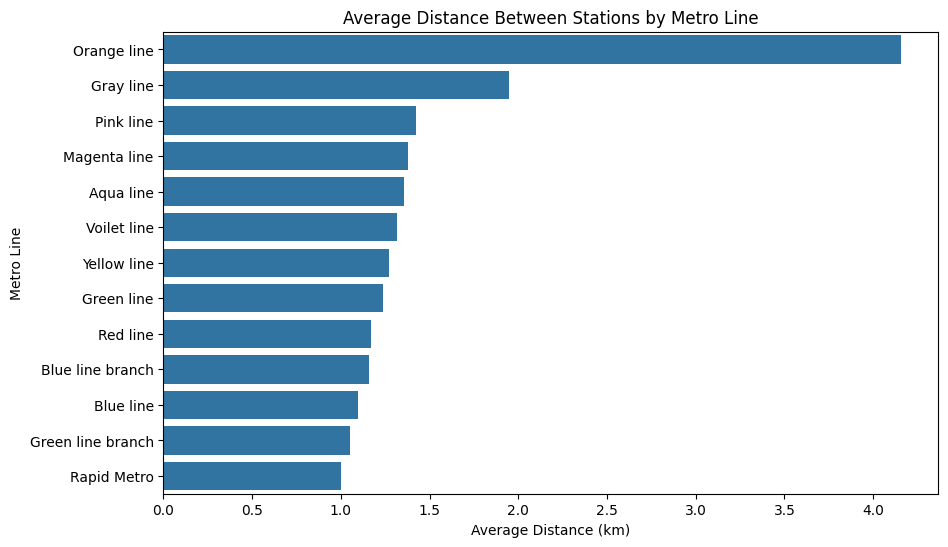

'Most other metro lines have average distances between ~1 to 1.5 km,\nshowing dense station placement suited for urban commuting and better accessibility.'

In [129]:
avg_line_distance = avg_line_distance.reset_index()

plt.figure(figsize=(10,6))
sns.barplot(
    data=avg_line_distance,
    x='Interstation Distance',
    y='Metro Line'
)

plt.title('Average Distance Between Stations by Metro Line')
plt.xlabel('Average Distance (km)')
plt.ylabel('Metro Line')

plt.show()

'''Orange Line has the highest average interstation distance (~4+ km),
indicating it serves longer routes with fewer stops, likely connecting distant or airport regions.'''

'''Most other metro lines have average distances between ~1 to 1.5 km,
showing dense station placement suited for urban commuting and better accessibility.'''